In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [39]:
nav = pd.read_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\clean_nav_history.csv"
)

performance = pd.read_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\clean_scheme_performance.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\10_benchmark_indices_clean.csv"
)

In [40]:
print("NAV Shape:", nav.shape)

print("Performance Shape:", performance.shape)

print("Benchmark Shape:", benchmark.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Benchmark Shape: (8050, 3)


In [41]:
print(nav.columns.tolist())

print(performance.columns.tolist())

print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['date', 'index_name', 'close_value']


In [42]:
display(nav.head())

display(performance.head())

display(benchmark.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [43]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [44]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [45]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

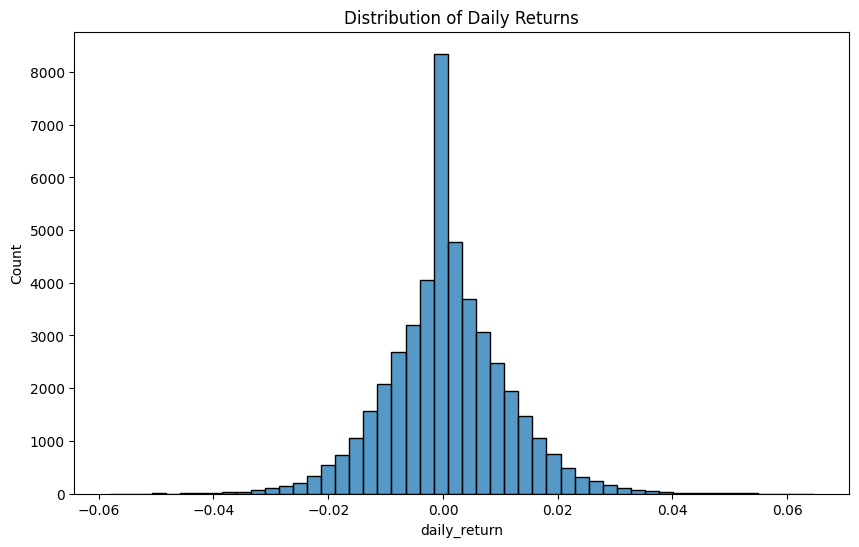

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
nav.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\nav_with_returns.csv",
    index=False
)

In [48]:
import os

print(
    "nav_with_returns.csv" in
    os.listdir(
        r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed"
    )
)

True


In [49]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
    ) / 365.25

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_table = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_table.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [50]:
cagr_table.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\cagr_table.csv",
    index=False
)

In [51]:
RF = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (
            returns.mean()
            - RF/252
        )
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [52]:
sharpe_df.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\sharpe_rankings.csv",
    index=False
)

In [53]:
import os

files = os.listdir(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed"
)

for file in files:
    print(file)

01_fund_master_clean.csv
03_aum_by_fund_house_clean.csv
04_monthly_sip_inflows_clean.csv
05_category_inflows_clean.csv
06_industry_folio_count_clean.csv
09_portfolio_holdings_clean.csv
10_benchmark_indices_clean.csv
alpha_beta.csv
cagr_table.csv
clean_investor_transactions.csv
clean_nav_history.csv
clean_scheme_performance.csv
fund_scorecard.csv
hhi_report.csv
max_drawdown.csv
nav_with_returns.csv
sharpe_rankings.csv
sortino_rankings.csv
var_cvar_report.csv


In [54]:
cagr_table.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [55]:
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [56]:
RF = 0.065

sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (
            returns.mean()
            - RF/252
        )
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [57]:
sortino_df.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\sortino_rankings.csv",
    index=False
)

In [58]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    running_max = (
        df["nav"]
        .cummax()
    )

    drawdown = (
        df["nav"]
        /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [fund, max_dd]
    )

max_dd_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [59]:
max_dd_df.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\max_drawdown.csv",
    index=False
)

In [60]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [61]:
max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [62]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [63]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [64]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [65]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, stderr = (
            linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [66]:
alpha_beta_df.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\alpha_beta.csv",
    index=False
)

In [67]:
scorecard = (
    performance[
        [
            "amfi_code",
            "scheme_name",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        max_dd_df,
        on="amfi_code"
    )
)

In [68]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [69]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head()

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,75.2500


In [70]:
scorecard.to_csv(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed\fund_scorecard.csv",
    index=False
)

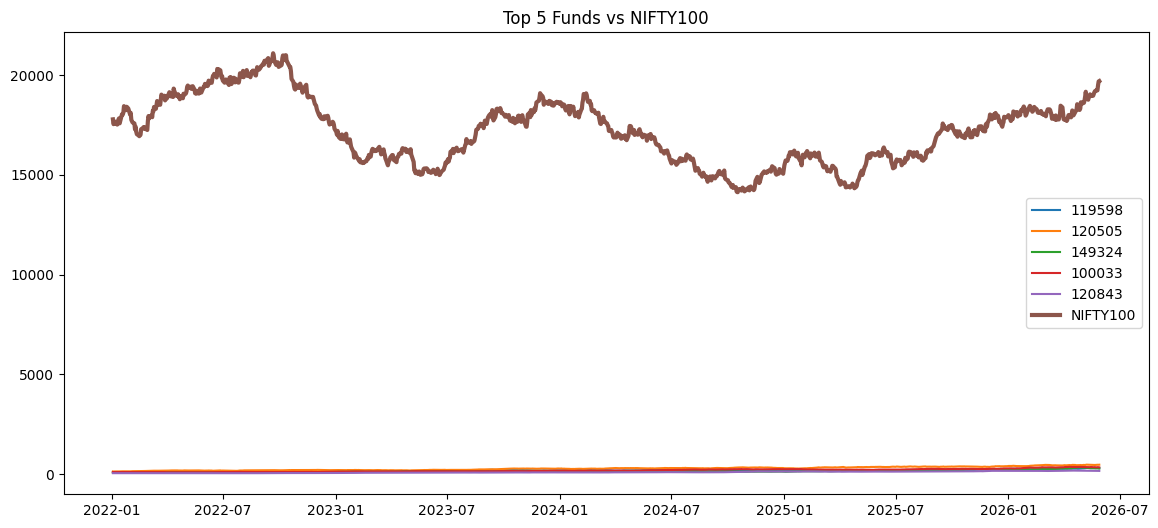

In [71]:
top5 = (
    scorecard["amfi_code"]
    .head(5)
    .tolist()
)

plt.figure(figsize=(14,6))

for fund in top5:

    df = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100",
    linewidth=3
)

plt.legend()

plt.title(
    "Top 5 Funds vs NIFTY100"
)

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
import os

print(
    os.listdir(
        r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed"
    )
)

['01_fund_master_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv', 'alpha_beta.csv', 'cagr_table.csv', 'clean_investor_transactions.csv', 'clean_nav_history.csv', 'clean_scheme_performance.csv', 'fund_scorecard.csv', 'hhi_report.csv', 'max_drawdown.csv', 'nav_with_returns.csv', 'sharpe_rankings.csv', 'sortino_rankings.csv', 'var_cvar_report.csv']


In [73]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [74]:
scorecard[
    ["scheme_name","fund_score"]
].head()

,scheme_name,fund_score
2,SBI Small Cap Fund - Regular Plan - Growth,83.3750
12,ICICI Pru Midcap Fund - Regular - Growth,82.2500
39,DSP Small Cap Fund - Regular - Growth,77.9375
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.0000
22,Kotak Flexicap Fund - Regular - Growth,75.2500


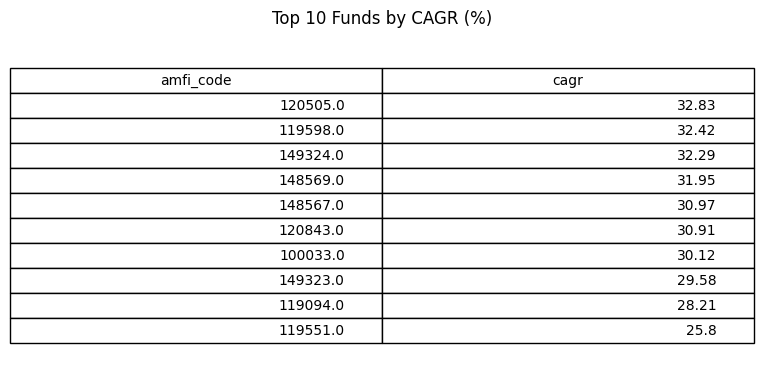

In [75]:
import matplotlib.pyplot as plt

cagr_display = cagr_table.copy()

cagr_display["cagr"] = (
    cagr_display["cagr"] * 100
).round(2)

cagr_display = (
    cagr_display
    .sort_values(
        "cagr",
        ascending=False
    )
    .head(10)
)

fig, ax = plt.subplots(figsize=(8,4))

ax.axis("off")

table = ax.table(
    cellText=cagr_display.values,
    colLabels=cagr_display.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.5)

plt.title(
    "Top 10 Funds by CAGR (%)",
    pad=20
)

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\cagr_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

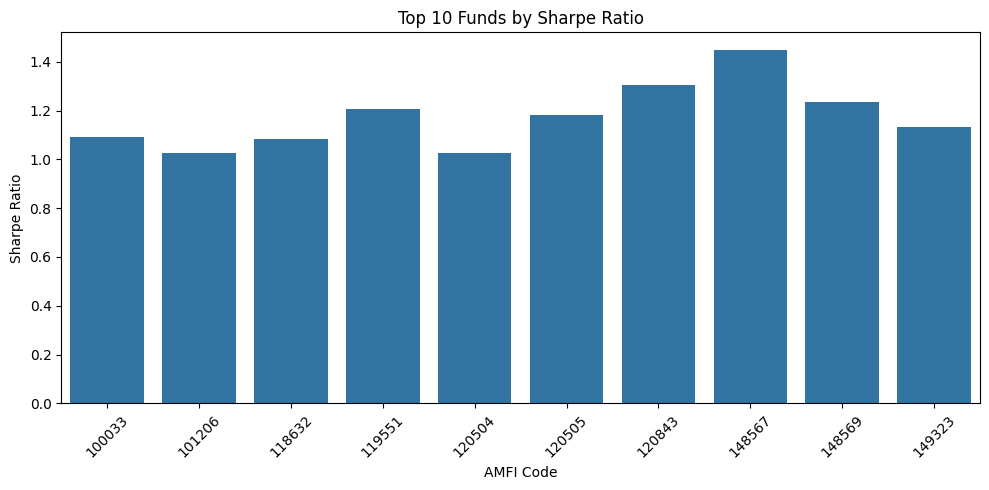

In [76]:
plt.figure(figsize=(10,5))

top_sharpe = (
    sharpe_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\sharpe_ratio_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

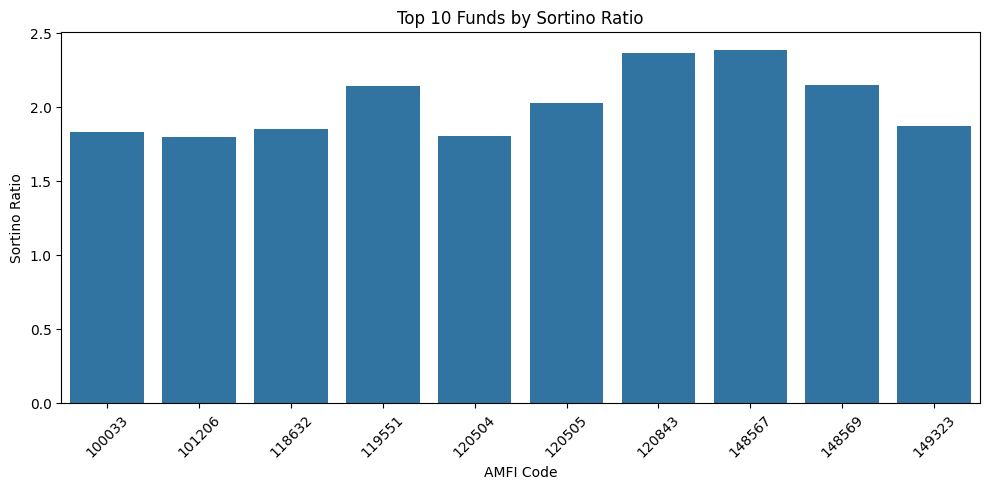

In [77]:
plt.figure(figsize=(10,5))

top_sortino = (
    sortino_df
    .sort_values(
        "sortino_ratio",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_sortino,
    x="amfi_code",
    y="sortino_ratio"
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\sortino_ratio_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

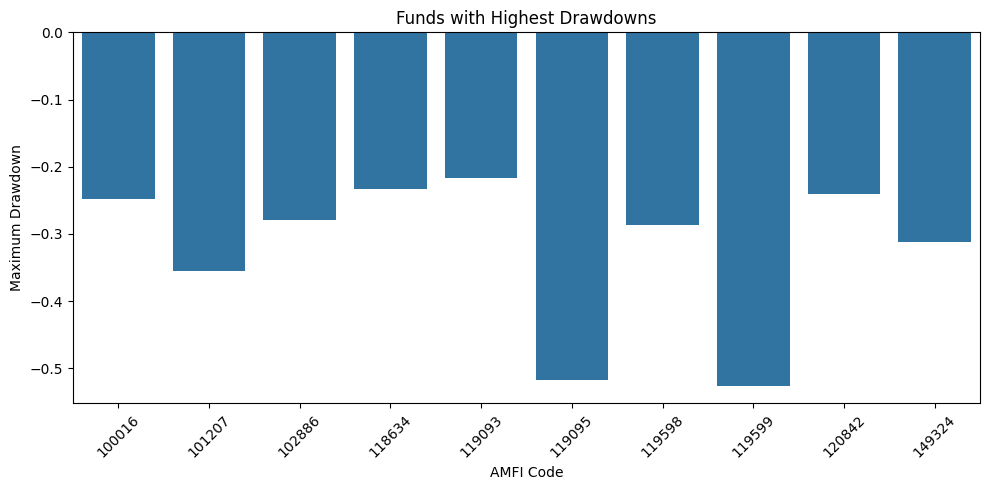

In [78]:
plt.figure(figsize=(10,5))

top_drawdown = (
    max_dd_df
    .sort_values(
        "max_drawdown"
    )
    .head(10)
)

sns.barplot(
    data=top_drawdown,
    x="amfi_code",
    y="max_drawdown"
)

plt.title(
    "Funds with Highest Drawdowns"
)

plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\max_drawdown_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

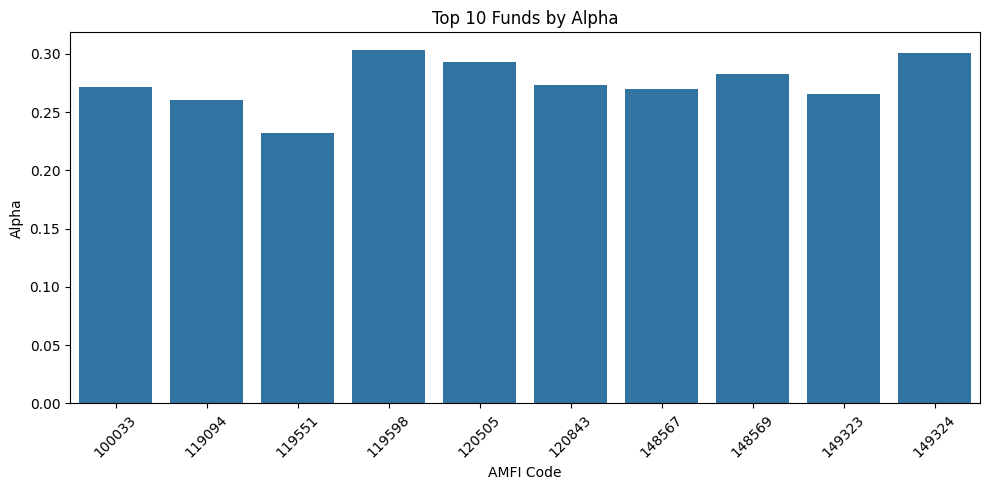

In [79]:
plt.figure(figsize=(10,5))

top_alpha = (
    alpha_beta_df
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_alpha,
    x="amfi_code",
    y="alpha"
)

plt.title(
    "Top 10 Funds by Alpha"
)

plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\alpha_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

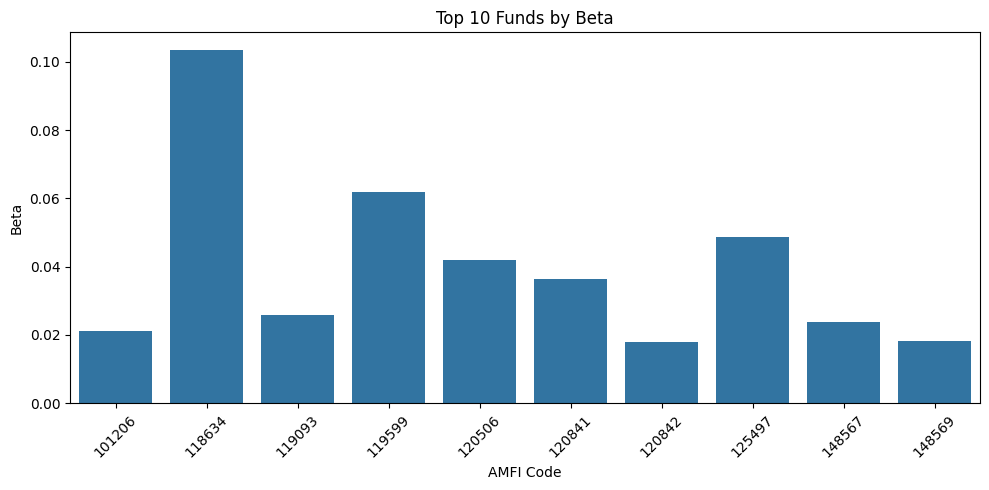

In [80]:
plt.figure(figsize=(10,5))

top_beta = (
    alpha_beta_df
    .sort_values(
        "beta",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_beta,
    x="amfi_code",
    y="beta"
)

plt.title(
    "Top 10 Funds by Beta"
)

plt.xlabel("AMFI Code")
plt.ylabel("Beta")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\beta_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

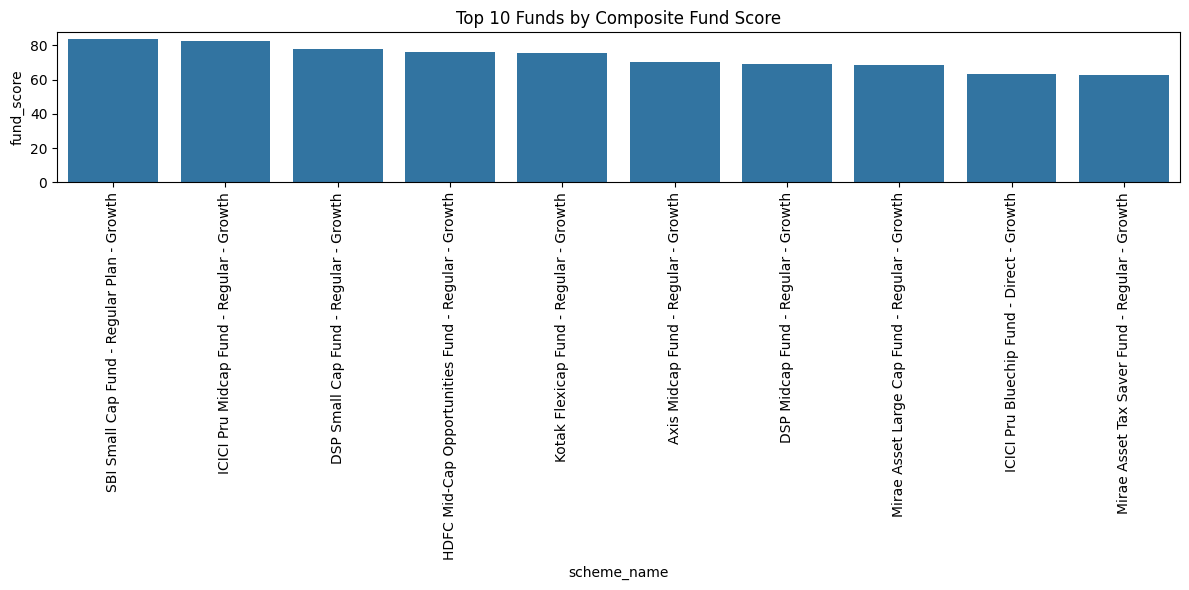

In [81]:
plt.figure(figsize=(12,6))

top_funds = (
    scorecard
    .head(10)
)

sns.barplot(
    data=top_funds,
    x="scheme_name",
    y="fund_score"
)

plt.title(
    "Top 10 Funds by Composite Fund Score"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\top_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()